In [ ]:
from google.colab import files
uploaded = files.upload()

Saving student (2).csv to student (2) (1).csv


In [ ]:
import pandas as pd

student_df = pd.read_csv('student (2).csv')

# Lihat 5 data pertama
student_df.head()

,Unnamed: 0,Id,Student_Age,Sex,High_School_Type,Scholarship,Additional_Work,Sports_activity,Transportation,Weekly_Study_Hours,Attendance,Reading,Notes,Listening_in_Class,Project_work,Grade
0,0,5001,21,Male,Other,50%,Yes,No,Private,0,Always,Yes,Yes,No,No,AA
1,1,5002,20,Male,Other,50%,Yes,No,Private,0,Always,Yes,No,Yes,Yes,AA
2,2,5003,21,Male,State,50%,No,No,Private,2,Never,No,No,No,Yes,AA
3,3,5004,18,Female,Private,50%,Yes,No,Bus,2,Always,No,Yes,No,No,AA
4,4,5005,22,Male,Private,50%,No,No,Bus,12,Always,Yes,No,Yes,Yes,AA


Kode tersebut digunakan untuk membaca file dataset ke dalam program dan menampilkan 5 data pertama untuk melihat gambaran awal isi data.

In [ ]:
student_df['Sex'].value_counts()


,count
Sex,
Male,87
Female,58


Kode tersebut digunakan untuk menghitung jumlah masing-masing kategori pada kolom **Sex**, sehingga diketahui berapa banyak siswa laki-laki dan perempuan dalam dataset.


In [ ]:
#seeing df shape, dtypes and null values
print(student_df.shape)
student_df.info() #the aren't null values !

(145, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Student_Age         145 non-null    int64 
 1   Sex                 145 non-null    object
 2   High_School_Type    145 non-null    object
 3   Scholarship         144 non-null    object
 4   Additional_Work     145 non-null    object
 5   Sports_activity     145 non-null    object
 6   Transportation      145 non-null    object
 7   Weekly_Study_Hours  145 non-null    int64 
 8   Attendance          145 non-null    object
 9   Reading             145 non-null    object
 10  Notes               145 non-null    object
 11  Listening_in_Class  145 non-null    object
 12  Project_work        145 non-null    object
 13  Grade               145 non-null    object
dtypes: int64(2), object(12)
memory usage: 16.0+ KB


Kode tersebut digunakan untuk melihat ukuran dataset, tipe data setiap kolom, dan mengecek apakah ada nilai kosong (null).

shape menampilkan jumlah baris dan kolom, sedangkan info() menampilkan detail tipe data serta jumlah data yang tidak kosong pada tiap kolom.

In [ ]:
#checking categorial values for object type columns
for column in student_df.select_dtypes(include='object').columns:
    print(f"{column}, {student_df[column].unique()}")

Sex, ['Male' 'Female']
High_School_Type, ['Other' 'State' 'Private']
Scholarship, ['50%' '75%' '100%' '25%' nan]
Additional_Work, ['Yes' 'No']
Sports_activity, ['No' 'Yes']
Transportation, ['Private' 'Bus']
Attendance, ['Always' 'Never' 'Sometimes' '3']
Reading, ['Yes' 'No']
Notes, ['Yes' 'No' '6']
Listening_in_Class, ['No' 'Yes' '6']
Project_work, ['No' 'Yes']
Grade, ['AA' 'BA' 'CC' 'Fail' 'BB' 'CB' 'DD' 'DC']


Kode tersebut digunakan untuk menampilkan semua nilai unik pada setiap kolom bertipe kategorikal (object).

Tujuannya adalah untuk mengetahui kategori apa saja yang ada serta mendeteksi jika terdapat nilai yang tidak sesuai atau error dalam data.

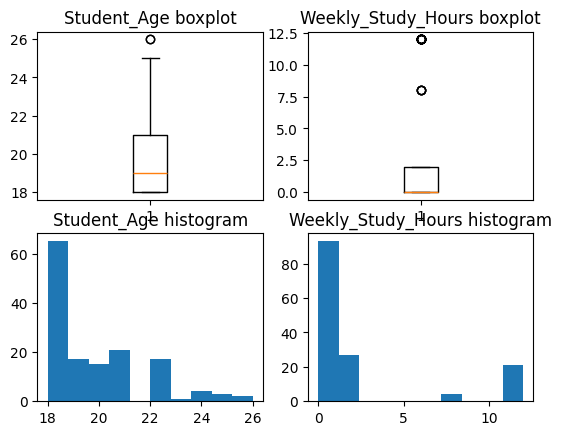

In [ ]:
#checking numerical columns distribution
fig, axes = plt.subplots(2,2)
for i, column in enumerate(student_df.select_dtypes(include='number').columns):
    if i <= 1:
        axes[0][i].boxplot(student_df[column])
        axes[0][i].set_title(f'{column} boxplot')
        axes[1][i].hist(student_df[column])
        axes[1][i].set_title(f'{column} histogram')


plt.show()

Visualisasi menampilkan distribusi dua variabel numerik, yaitu Student_Age dan Weekly_Study_Hours, dalam bentuk boxplot dan histogram.

Pada Student_Age, data berada pada rentang sekitar 18–26 tahun dengan median sekitar 19–20 tahun. Sebaran relatif normal dan tidak terdapat outlier ekstrem.

Pada Weekly_Study_Hours, sebagian besar siswa memiliki jam belajar rendah (mendekati 0–2 jam), namun terdapat beberapa nilai tinggi (sekitar 8–12 jam) yang muncul sebagai outlier.

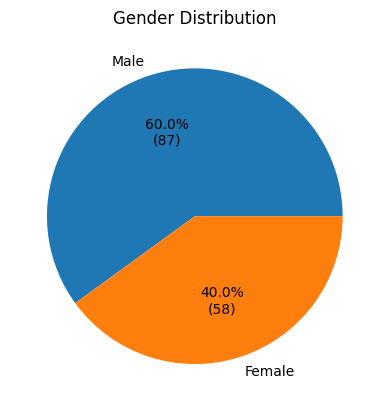

In [ ]:
plt.figure()
plt.pie(sex_counts,
        labels=sex_counts.index,
        autopct=lambda p: f'{p:.1f}%\n({int(p/100*sum(sex_counts))})')
plt.title('Gender Distribution')
plt.show()

Diagram lingkaran menunjukkan bahwa 60% (87 siswa) merupakan laki-laki dan 40% (58 siswa) merupakan perempuan dari total 145 siswa.

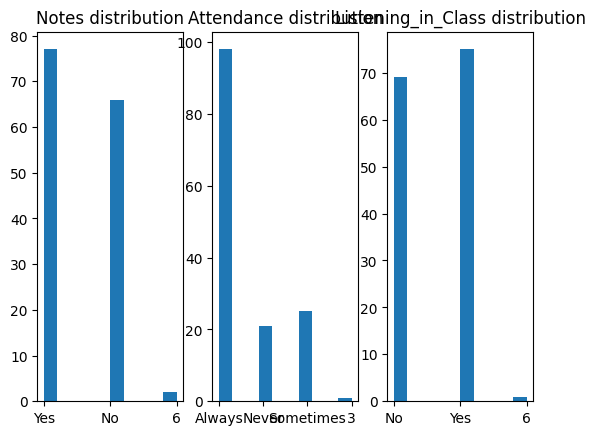

In [ ]:
fig, axs = plt.subplots(1,3)
axs[0].hist(student_df['Notes'])
axs[0].set_title('Notes distribution')

axs[1].hist(student_df['Attendance'])
axs[1].set_title('Attendance distribution')

axs[2].hist(student_df['Listening_in_Class'])
axs[2].set_title('Listening_in_Class distribution')

plt.show()

Histogram menunjukkan distribusi variabel Notes, Attendance, dan Listening_in_Class. Sebagian besar siswa menunjukkan perilaku positif seperti membuat catatan, hadir secara konsisten, dan memperhatikan di kelas. Namun, terdapat beberapa nilai tidak valid (seperti '6' dan '3') yang mengindikasikan perlunya proses pembersihan data sebelum analisis lebih lanjut.

<Axes: >

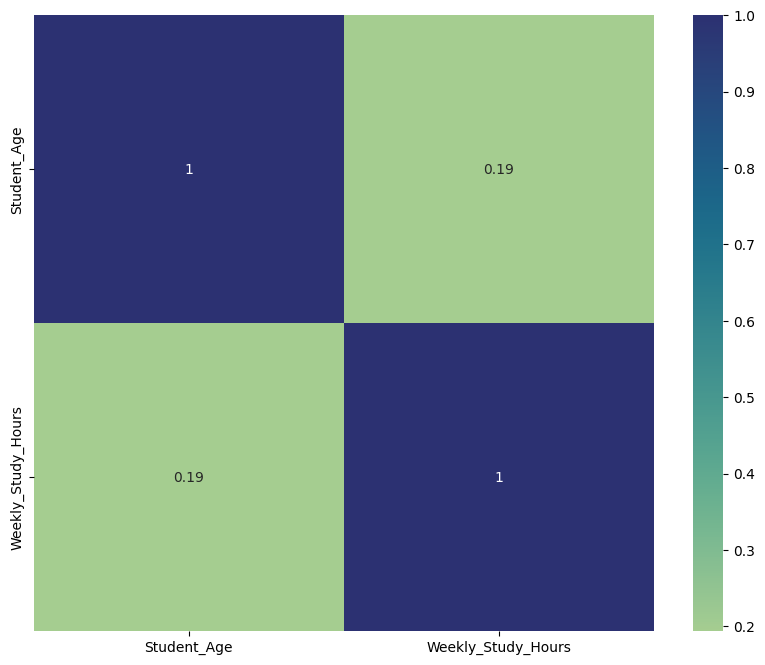

In [ ]:
numerical_columns = student_df.select_dtypes(include='number').columns
corr = student_df[numerical_columns].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="crest")

Heatmap ini menunjukkan hubungan antara umur siswa (Student_Age) dan jam belajar per minggu (Weekly_Study_Hours).

Angka 0.19 berarti hubungan keduanya sangat lemah.
Artinya, umur siswa hampir tidak berpengaruh terhadap banyaknya jam belajar per minggu.

Nilai 1 yang ada di diagonal itu normal, karena menunjukkan variabel dibandingkan dengan dirinya sendiri (pasti hasilnya 1).

jadi, umur siswa tidak terlalu berhubungan dengan lama waktu belajar mereka.

<Axes: xlabel='High_School_Type', ylabel='Grade'>

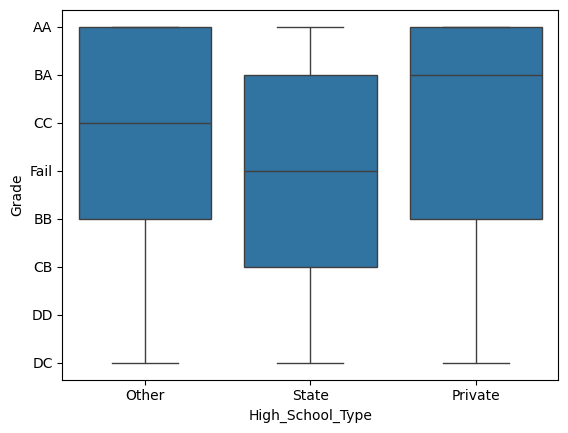

In [ ]:
sns.boxplot(data=student_df, x="High_School_Type", y="Grade")

Boxplot menunjukkan bahwa siswa dari sekolah Private cenderung memiliki nilai sedikit lebih tinggi dibandingkan State dan Other. Namun, perbedaannya tidak terlalu besar karena sebaran nilainya masih saling tumpang tindih.

In [ ]:
student_df.groupby('High_School_Type')['Grade'].value_counts()

High_School_Type  Grade
Other             AA        6
                  CC        4
                  BA        2
                  DD        2
                  BB        1
                  CB        1
                  DC        1
Private           AA        8
                  BA        5
                  BB        3
                  CB        2
                  DD        2
                  Fail      2
                  DC        1
State             AA       21
                  BA       16
                  BB       16
                  CC       13
                  DD       12
                  DC       11
                  CB        7
                  Fail      6
Name: count, dtype: int64

Tabel menunjukkan jumlah masing-masing kategori nilai pada setiap jenis sekolah.

Pada sekolah State, jumlah siswa paling banyak dan distribusi nilai relatif merata, dengan nilai AA (21 siswa) sebagai yang terbanyak, diikuti BA dan BB (masing-masing 16 siswa).

Pada sekolah Private, nilai yang paling banyak diperoleh adalah AA (8 siswa), diikuti BA (5 siswa).

Sedangkan pada sekolah Other, jumlah siswa lebih sedikit, dengan nilai AA (6 siswa) sebagai yang paling banyak.

Secara umum, sekolah State memiliki jumlah siswa terbanyak dengan variasi nilai yang lebih beragam, sementara sekolah Private dan Other memiliki jumlah siswa lebih sedikit.

In [ ]:
student_df.groupby('Sports_activity')['Scholarship'].value_counts() / student_df['Sports_activity'].value_counts()

Sports_activity  Scholarship
No               50%            0.588235
                 75%            0.282353
                 100%           0.117647
Yes              50%            0.438596
                 75%            0.298246
                 100%           0.228070
                 25%            0.035088
Name: count, dtype: float64

Perhitungan ini menunjukkan proporsi siswa yang menerima dan tidak menerima beasiswa pada setiap kategori kegiatan olahraga. Hasilnya memperlihatkan perbandingan persentase beasiswa antara siswa yang mengikuti kegiatan olahraga dan yang tidak, sehingga dapat dianalisis apakah terdapat kecenderungan tertentu antara partisipasi olahraga dan penerimaan beasiswa.